# Component 4 PP2 Full Notebook With Visualizations

Trust-Aware Review Intelligence Framework. Includes dataset loading, Isolation Forest, Multi-Task Bi-LSTM + Attention, evaluation, graphs, confusion matrices, F1-score charts, demo review confidence heatmap, provider ranking, and model saving.

In [ ]:
!pip install tensorflow scikit-learn pandas numpy matplotlib openpyxl joblib -q

In [ ]:
import os, random, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Check CSV Paths

In [ ]:
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Research_Datasets/customer_reviews_25k.csv
/content/drive/MyDrive/Research_Datasets/aspect_sentiment_labels_25k.csv
/content/drive/MyDrive/Research_Datasets/review_credibility_25k.csv
/content/drive/MyDrive/Research_Datasets/provider_review_summary_5k.csv
/content/drive/MyDrive/Research_Datasets/Component4_Outputs/component4_test_predictions.csv
/content/drive/MyDrive/Research_Datasets/Component4_Outputs/component4_provider_rankings.csv


## 3. Load Datasets

In [ ]:
DATASET_DIR = '/content/drive/MyDrive/Research_Datasets'

reviews = pd.read_csv(f'{DATASET_DIR}/customer_reviews_25k.csv')
aspect_labels = pd.read_csv(f'{DATASET_DIR}/aspect_sentiment_labels_25k.csv')
credibility = pd.read_csv(f'{DATASET_DIR}/review_credibility_25k.csv')
summary_path = f'{DATASET_DIR}/provider_review_summary_5k.csv'
provider_summary = pd.read_csv(summary_path) if os.path.exists(summary_path) else None

print('Reviews:', reviews.shape)
print('Aspect labels:', aspect_labels.shape)
print('Credibility:', credibility.shape)
if provider_summary is not None:
    print('Provider summary:', provider_summary.shape)

display(reviews.head())
display(aspect_labels.head())
display(credibility.head())

Reviews: (25000, 11)
Aspect labels: (25000, 6)
Credibility: (25000, 13)
Provider summary: (4998, 13)


,review_id,booking_id,provider_id,user_id,service_type,district,rating,review_text,review_date,verified_booking,dataset_split
0,R00001,B234652,P010234,U34114,Masons,Matara,1,EXCELLENT EXCELLENT EXCELLENT service!!! Best ...,2025-09-21,0,train
1,R00002,B380896,P020134,U71066,Carpenters,Nuwara Eliya,5,Perfect work 100% recommended visit http://ser...,2025-11-27,0,test
2,R00003,B192559,P030016,U12777,Tile Workers,Jaffna,4,"For the bathroom tile work, bathroom tile work...",2025-07-26,1,train
3,R00004,B585697,P040029,U72068,Plumbers,Matara,2,"During the tap repair job, work quality was po...",2025-07-07,0,train
4,R00005,B246515,P050254,U18115,Electricians,Batticaloa,5,"During the switch board job, quality eka honda...",2025-03-19,0,train


,review_id,quality_label,punctuality_label,communication_label,professionalism_label,overall_sentiment_label
0,R00001,Positive,Positive,Neutral,Negative,Neutral
1,R00002,Negative,Positive,Positive,Negative,Neutral
2,R00003,Positive,Positive,Positive,Positive,Positive
3,R00004,Negative,Negative,Negative,Negative,Negative
4,R00005,Positive,Positive,Positive,Neutral,Positive


,review_id,word_count,exclamation_count,caps_word_count,repeated_char_count,unique_word_ratio,url_count,duplicate_pattern,extreme_rating,verified_booking,reviewer_review_count_24h,is_fake_review,credibility_score
0,R00001,7,6,3,2,0.714,0,0,1,0,1,1,0.203
1,R00002,6,0,0,0,1.000,1,1,1,0,8,1,0.157
2,R00003,14,0,0,0,0.786,0,0,0,1,1,0,0.905
3,R00004,15,0,0,0,1.000,0,0,0,0,1,0,0.718
4,R00005,22,0,0,0,0.909,0,0,1,0,1,0,0.720


## 4. Merge Datasets

In [ ]:
df = reviews.merge(aspect_labels, on='review_id', how='inner')
df = df.merge(credibility, on='review_id', how='inner')

if 'rating_x' in df.columns and 'rating' not in df.columns:
    df['rating'] = df['rating_x']

print('Merged dataset:', df.shape)
display(df.head())

Merged dataset: (25000, 28)


,review_id,booking_id,provider_id,user_id,service_type,district,rating,review_text,review_date,verified_booking_x,...,caps_word_count,repeated_char_count,unique_word_ratio,url_count,duplicate_pattern,extreme_rating,verified_booking_y,reviewer_review_count_24h,is_fake_review,credibility_score
0,R00001,B234652,P010234,U34114,Masons,Matara,1,EXCELLENT EXCELLENT EXCELLENT service!!! Best ...,2025-09-21,0,...,3,2,0.714,0,0,1,0,1,1,0.203
1,R00002,B380896,P020134,U71066,Carpenters,Nuwara Eliya,5,Perfect work 100% recommended visit http://ser...,2025-11-27,0,...,0,0,1.000,1,1,1,0,8,1,0.157
2,R00003,B192559,P030016,U12777,Tile Workers,Jaffna,4,"For the bathroom tile work, bathroom tile work...",2025-07-26,1,...,0,0,0.786,0,0,0,1,1,0,0.905
3,R00004,B585697,P040029,U72068,Plumbers,Matara,2,"During the tap repair job, work quality was po...",2025-07-07,0,...,0,0,1.000,0,0,0,0,1,0,0.718
4,R00005,B246515,P050254,U18115,Electricians,Batticaloa,5,"During the switch board job, quality eka honda...",2025-03-19,0,...,0,0,0.909,0,0,1,0,1,0,0.720


## 5. Dataset Validation

In [ ]:
aspect_columns = ['quality_label','punctuality_label','communication_label','professionalism_label']

print('Missing values:')
print(df.isnull().sum())

print('\nService type distribution:')
print(df['service_type'].value_counts())

for col in aspect_columns:
    print('\n', col)
    print(df[col].value_counts())

Missing values:
review_id                    0
booking_id                   0
provider_id                  0
user_id                      0
service_type                 0
district                     0
rating                       0
review_text                  0
review_date                  0
verified_booking_x           0
dataset_split                0
quality_label                0
punctuality_label            0
communication_label          0
professionalism_label        0
overall_sentiment_label      0
word_count                   0
exclamation_count            0
caps_word_count              0
repeated_char_count          0
unique_word_ratio            0
url_count                    0
duplicate_pattern            0
extreme_rating               0
verified_booking_y           0
reviewer_review_count_24h    0
is_fake_review               0
credibility_score            0
dtype: int64

Service type distribution:
service_type
A/C Technicians     1824
Carpenters          1820
Tile Workers

# Dataset Overview Visualizations

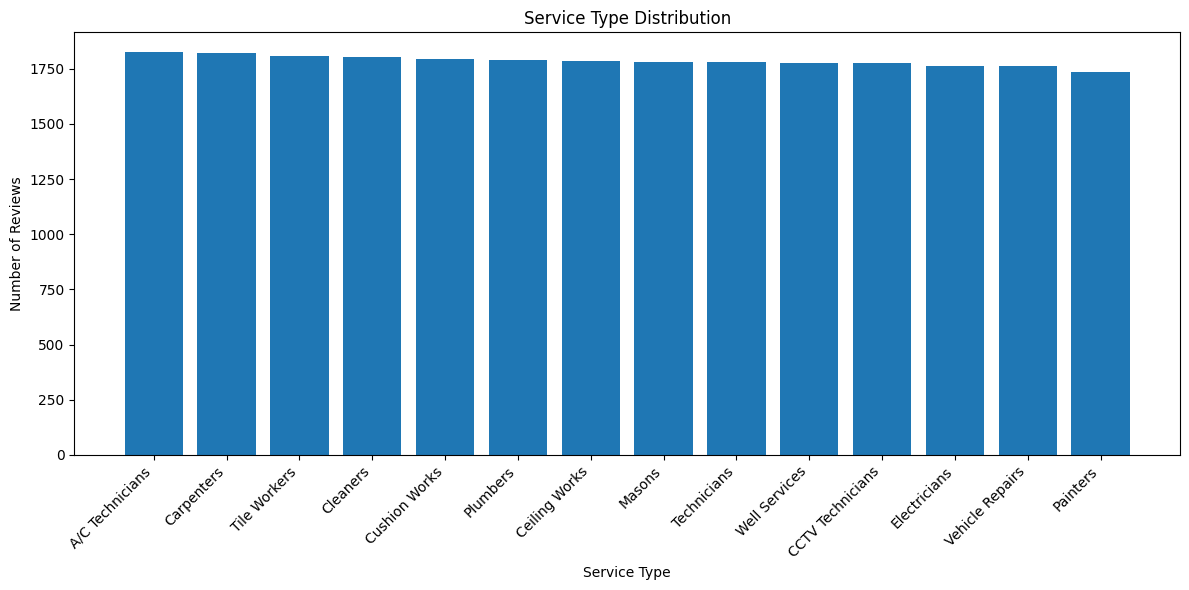

In [ ]:
# Service type distribution
plt.figure(figsize=(12,6))
service_counts = df['service_type'].value_counts()
plt.bar(service_counts.index, service_counts.values)
plt.title('Service Type Distribution')
plt.xlabel('Service Type')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

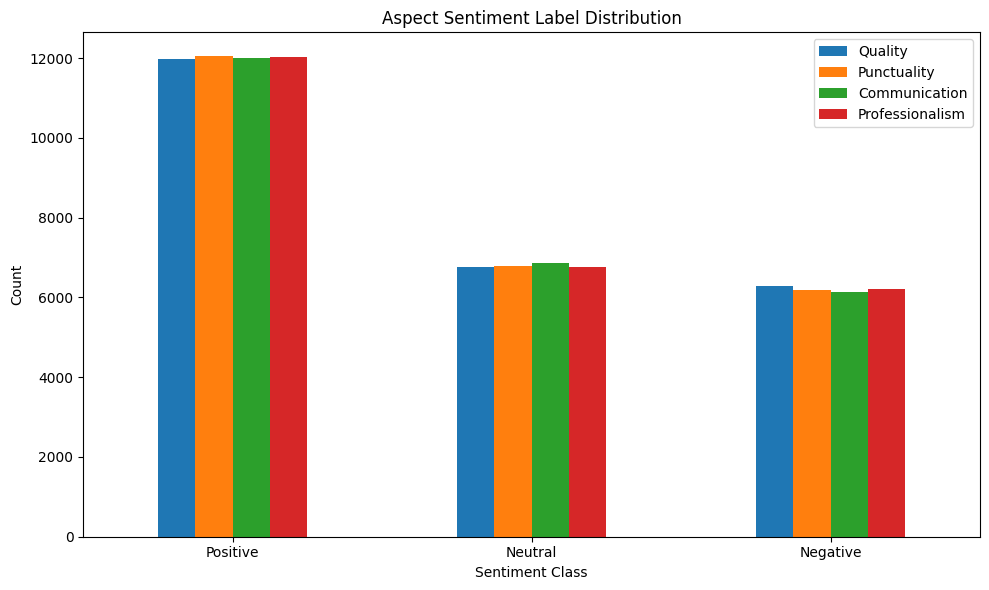

,Quality,Punctuality,Communication,Professionalism
Positive,11972,12042,12012,12024
Neutral,6749,6774,6862,6767
Negative,6279,6184,6126,6209


In [ ]:
# Aspect sentiment label distribution
label_summary = {}
for col in aspect_columns:
    label_summary[col.replace('_label','').title()] = df[col].value_counts()
label_df = pd.DataFrame(label_summary).fillna(0)

label_df.plot(kind='bar', figsize=(10,6))
plt.title('Aspect Sentiment Label Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(label_df)

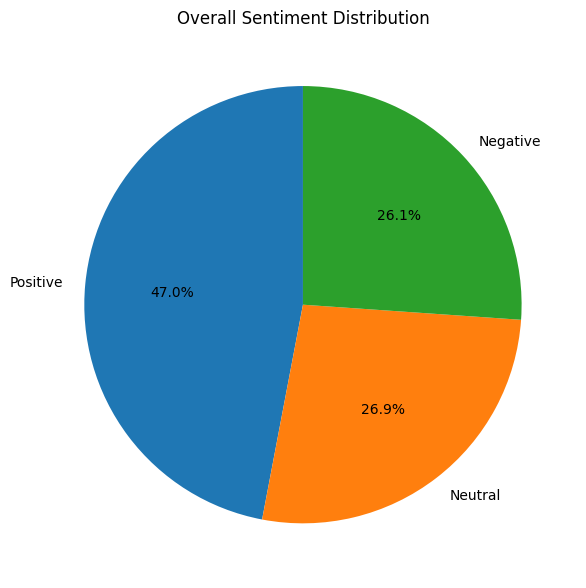

In [ ]:
# Overall sentiment pie chart
def majority_sentiment(row):
    values = [row[col] for col in aspect_columns]
    return pd.Series(values).mode()[0]

df['overall_majority_sentiment'] = df.apply(majority_sentiment, axis=1)
sent_counts = df['overall_majority_sentiment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sent_counts.values, labels=sent_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall Sentiment Distribution')
plt.tight_layout()
plt.show()

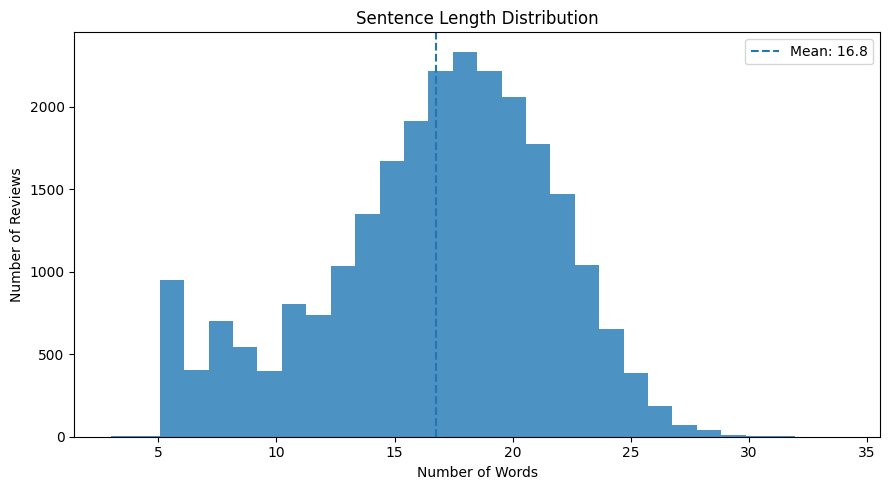

In [ ]:
# Sentence length distribution
df['sentence_length'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
mean_len = df['sentence_length'].mean()

plt.figure(figsize=(9,5))
plt.hist(df['sentence_length'], bins=30, alpha=0.8)
plt.axvline(mean_len, linestyle='--', label=f'Mean: {mean_len:.1f}')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.show()

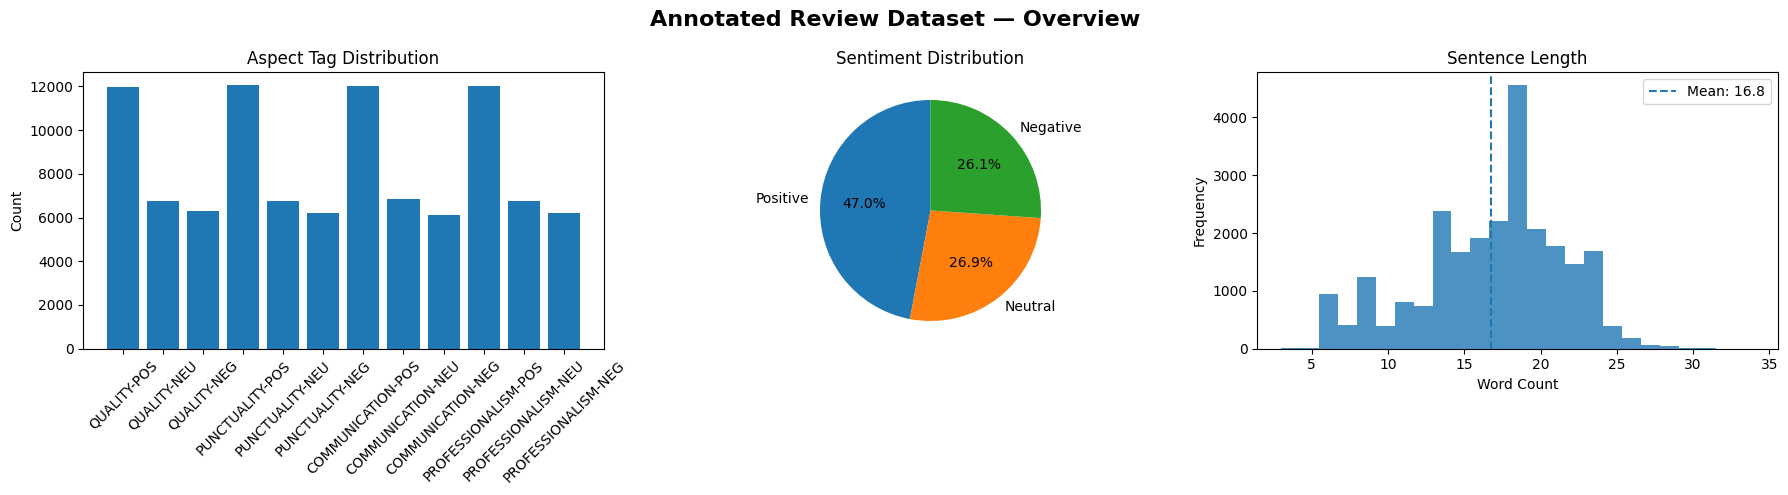

In [ ]:
# Combined overview chart similar to old notebook
fig, axes = plt.subplots(1, 3, figsize=(18,5))

aspect_count_values, aspect_count_names = [], []
for aspect in aspect_columns:
    aspect_name = aspect.replace('_label','').upper()
    for label in ['Positive','Neutral','Negative']:
        aspect_count_names.append(f'{aspect_name}-{label[:3].upper()}')
        aspect_count_values.append((df[aspect] == label).sum())

axes[0].bar(aspect_count_names, aspect_count_values)
axes[0].set_title('Aspect Tag Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(sent_counts.values, labels=sent_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Distribution')

axes[2].hist(df['sentence_length'], bins=25, alpha=0.8)
axes[2].axvline(mean_len, linestyle='--', label=f'Mean: {mean_len:.1f}')
axes[2].set_title('Sentence Length')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

fig.suptitle('Annotated Review Dataset — Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Part A - Isolation Forest Fake Review Detection

In [ ]:
candidate_fake_features = ['word_count','exclamation_count','caps_word_count','repeated_characters','rating','diversity_score','url_count','extreme_rating','duplicate_pattern']
fake_features = [col for col in candidate_fake_features if col in df.columns]
print('Fake review features:', fake_features)

Fake review features: ['word_count', 'exclamation_count', 'caps_word_count', 'rating', 'url_count', 'extreme_rating', 'duplicate_pattern']


## Train / Validation / Test Split

In [ ]:
if 'dataset_split' in df.columns:
    train_df = df[df['dataset_split'] == 'train'].copy()
    val_df = df[df['dataset_split'].isin(['validation','val'])].copy()
    test_df = df[df['dataset_split'] == 'test'].copy()
    if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
        train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['quality_label'])
        val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['quality_label'])
else:
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['quality_label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['quality_label'])

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

Train: (17466, 30)
Validation: (3761, 30)
Test: (3773, 30)


In [ ]:
scaler = StandardScaler()
X_fake_train = scaler.fit_transform(train_df[fake_features])
X_fake_val = scaler.transform(val_df[fake_features])
X_fake_test = scaler.transform(test_df[fake_features])

iso_forest = IsolationForest(n_estimators=200, contamination=0.10, random_state=SEED)
iso_forest.fit(X_fake_train)
print('Isolation Forest training completed.')

Isolation Forest training completed.



Train Fake Review Detection Report
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97     15714
        Fake       0.77      0.77      0.77      1752

    accuracy                           0.95     17466
   macro avg       0.87      0.87      0.87     17466
weighted avg       0.95      0.95      0.95     17466



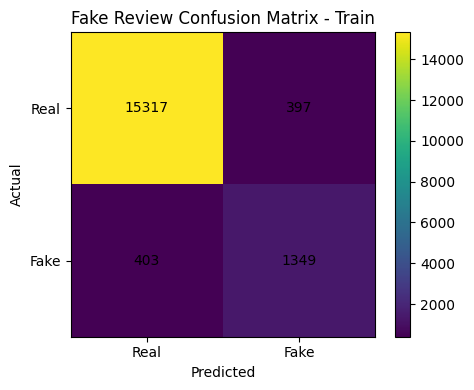


Validation Fake Review Detection Report
              precision    recall  f1-score   support

        Real       0.98      0.97      0.98      3387
        Fake       0.77      0.81      0.79       374

    accuracy                           0.96      3761
   macro avg       0.88      0.89      0.88      3761
weighted avg       0.96      0.96      0.96      3761



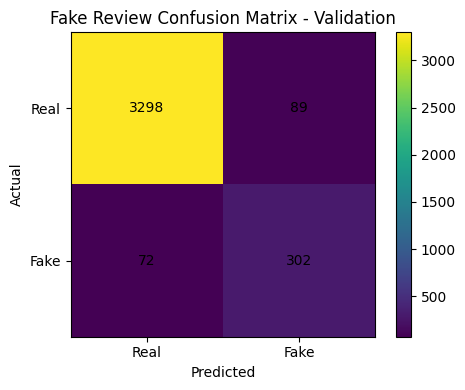


Test Fake Review Detection Report
              precision    recall  f1-score   support

        Real       0.98      0.97      0.98      3387
        Fake       0.77      0.80      0.79       386

    accuracy                           0.96      3773
   macro avg       0.87      0.89      0.88      3773
weighted avg       0.96      0.96      0.96      3773



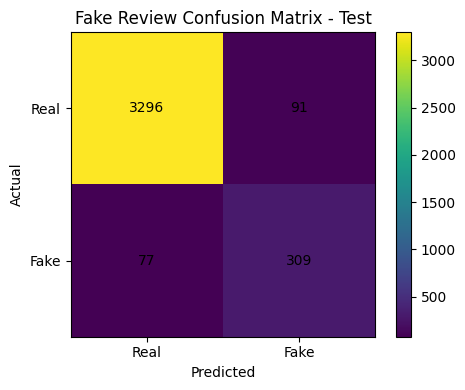

In [ ]:
def add_fake_predictions(split_df, X_scaled, split_name):
    split_df = split_df.copy()
    raw_pred = iso_forest.predict(X_scaled)
    split_df['predicted_fake_review'] = np.where(raw_pred == -1, 1, 0)
    split_df['anomaly_score'] = iso_forest.score_samples(X_scaled)
    mn, mx = split_df['anomaly_score'].min(), split_df['anomaly_score'].max()
    split_df['predicted_credibility_score'] = (split_df['anomaly_score'] - mn) / (mx - mn + 1e-8)

    print('\n' + '='*70)
    print(split_name, 'Fake Review Detection Report')
    print('='*70)
    if 'is_fake_review' in split_df.columns:
        print(classification_report(split_df['is_fake_review'], split_df['predicted_fake_review'], target_names=['Real','Fake'], zero_division=0))
        cm = confusion_matrix(split_df['is_fake_review'], split_df['predicted_fake_review'])
        plt.figure(figsize=(5,4))
        plt.imshow(cm)
        plt.title(f'Fake Review Confusion Matrix - {split_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks([0,1], ['Real','Fake'])
        plt.yticks([0,1], ['Real','Fake'])
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i,j], ha='center', va='center')
        plt.colorbar()
        plt.tight_layout()
        plt.show()
    return split_df

train_df = add_fake_predictions(train_df, X_fake_train, 'Train')
val_df = add_fake_predictions(val_df, X_fake_val, 'Validation')
test_df = add_fake_predictions(test_df, X_fake_test, 'Test')

# Part B - Multi-Task Bi-LSTM + Attention

In [ ]:
MAX_WORDS = 15000
MAX_LEN = 80

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>', lower=True)
tokenizer.fit_on_texts(train_df['review_text'].astype(str))

X_train_text = pad_sequences(tokenizer.texts_to_sequences(train_df['review_text'].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_text = pad_sequences(tokenizer.texts_to_sequences(val_df['review_text'].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_text = pad_sequences(tokenizer.texts_to_sequences(test_df['review_text'].astype(str)), maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_text.shape, X_val_text.shape, X_test_text.shape)

(17466, 80) (3761, 80) (3773, 80)


In [ ]:
label_encoders = {}
y_train, y_val, y_test = {}, {}, {}
for col in aspect_columns:
    enc = LabelEncoder()
    y_train[col] = enc.fit_transform(train_df[col])
    y_val[col] = enc.transform(val_df[col])
    y_test[col] = enc.transform(test_df[col])
    label_encoders[col] = enc
    print(col, '->', list(enc.classes_))

quality_label -> ['Negative', 'Neutral', 'Positive']
punctuality_label -> ['Negative', 'Neutral', 'Positive']
communication_label -> ['Negative', 'Neutral', 'Positive']
professionalism_label -> ['Negative', 'Neutral', 'Positive']


In [ ]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1],1), initializer='normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1],1), initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [ ]:
input_layer = Input(shape=(MAX_LEN,), name='review_input')
embedding = Embedding(input_dim=MAX_WORDS, output_dim=128, name='embedding_layer')(input_layer)
bilstm = Bidirectional(LSTM(96, return_sequences=True, dropout=0.35, recurrent_dropout=0.20), name='bi_lstm_layer')(embedding)
attention = AttentionLayer(name='attention_layer')(bilstm)
shared_dense = Dense(96, activation='relu', name='shared_dense')(attention)
shared_dropout = Dropout(0.40, name='shared_dropout')(shared_dense)

quality_output = Dense(3, activation='softmax', name='quality_label')(shared_dropout)
punctuality_output = Dense(3, activation='softmax', name='punctuality_label')(shared_dropout)
communication_output = Dense(3, activation='softmax', name='communication_label')(shared_dropout)
professionalism_output = Dense(3, activation='softmax', name='professionalism_label')(shared_dropout)

multi_task_model = Model(inputs=input_layer, outputs=[quality_output, punctuality_output, communication_output, professionalism_output])

multi_task_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'quality_label':'sparse_categorical_crossentropy',
        'punctuality_label':'sparse_categorical_crossentropy',
        'communication_label':'sparse_categorical_crossentropy',
        'professionalism_label':'sparse_categorical_crossentropy'
    },
    metrics={
        'quality_label':['accuracy'],
        'punctuality_label':['accuracy'],
        'communication_label':['accuracy'],
        'professionalism_label':['accuracy']
    }
)

multi_task_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review_input        │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 80, 128)   │  1,920,000 │ review_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_layer       │ (None, 80, 192)   │    172,800 │ embedding_layer[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 192)       │        272 │ bi_lstm_layer[0]… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 96)        │     18,528 │ attention_layer[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 96)        │          0 │ shared_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quality_label       │ (None, 3)         │        291 │ shared_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punctuality_label   │ (None, 3)         │        291 │ shared_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ communication_label │ (None, 3)         │        291 │ shared_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ professionalism_la… │ (None, 3)         │        291 │ shared_dropout[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,112,764 (8.06 MB)

 Trainable params: 2,112,764 (8.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_path = '/content/component4_multitask_bilstm_best.keras'
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history = multi_task_model.fit(
    X_train_text,
    {
        'quality_label': y_train['quality_label'],
        'punctuality_label': y_train['punctuality_label'],
        'communication_label': y_train['communication_label'],
        'professionalism_label': y_train['professionalism_label']
    },
    validation_data=(
        X_val_text,
        {
            'quality_label': y_val['quality_label'],
            'punctuality_label': y_val['punctuality_label'],
            'communication_label': y_val['communication_label'],
            'professionalism_label': y_val['professionalism_label']
        }
    ),
    epochs=20,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/20
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - communication_label_accuracy: 0.5021 - communication_label_loss: 1.0121 - loss: 3.8917 - professionalism_label_accuracy: 0.5177 - professionalism_label_loss: 0.9961 - punctuality_label_accuracy: 0.4995 - punctuality_label_loss: 1.0209 - quality_label_accuracy: 0.5881 - quality_label_loss: 0.8626
Epoch 1: val_loss improved from None to 1.37496, saving model to /content/component4_multitask_bilstm_best.keras

Epoch 1: finished saving model to /content/component4_multitask_bilstm_best.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 170s 577ms/step - communication_label_accuracy: 0.5953 - communication_label_loss: 0.8654 - loss: 3.1712 - professionalism_label_accuracy: 0.6154 - professionalism_label_loss: 0.8449 - punctuality_label_accuracy: 0.5784 - punctuality_label_loss: 0.9035 - quality_label_accuracy: 0.7555 - quality_label_loss: 0.5569 - val_communication_label_accuracy: 0.8407 - val_communication_label_loss: 0.3846 - val_loss: 1.3750 - val_

# Evaluation and Visualization

In [ ]:
print('Final Training and Validation Metrics')
print('='*70)
for key in history.history.keys():
    if 'accuracy' in key:
        print(key, ':', round(history.history[key][-1], 4))

print('\nTest Metrics')
print('='*70)
test_results = multi_task_model.evaluate(
    X_test_text,
    {
        'quality_label': y_test['quality_label'],
        'punctuality_label': y_test['punctuality_label'],
        'communication_label': y_test['communication_label'],
        'professionalism_label': y_test['professionalism_label']
    },
    verbose=0
)
for name, value in zip(multi_task_model.metrics_names, test_results):
    print(name, ':', round(value, 4))

Final Training and Validation Metrics
communication_label_accuracy : 0.8578
professionalism_label_accuracy : 0.8515
punctuality_label_accuracy : 0.873
quality_label_accuracy : 0.9586
val_communication_label_accuracy : 0.8551
val_professionalism_label_accuracy : 0.8484
val_punctuality_label_accuracy : 0.883
val_quality_label_accuracy : 0.9614

Test Metrics
loss : 0.9535
compile_metrics : 0.0953
quality_label_loss : 0.2633
punctuality_label_loss : 0.2923
communication_label_loss : 0.3026
professionalism_label_loss : 0.8635


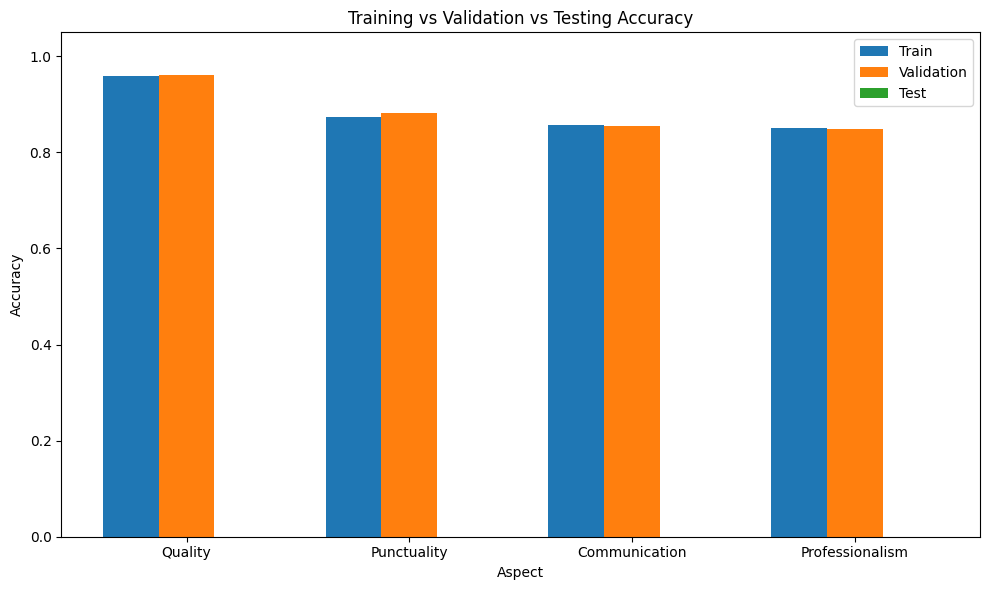

In [ ]:
aspect_display = ['Quality','Punctuality','Communication','Professionalism']
train_acc = [history.history['quality_label_accuracy'][-1], history.history['punctuality_label_accuracy'][-1], history.history['communication_label_accuracy'][-1], history.history['professionalism_label_accuracy'][-1]]
val_acc = [history.history['val_quality_label_accuracy'][-1], history.history['val_punctuality_label_accuracy'][-1], history.history['val_communication_label_accuracy'][-1], history.history['val_professionalism_label_accuracy'][-1]]
metric_dict = dict(zip(multi_task_model.metrics_names, test_results))
test_acc = [metric_dict.get('quality_label_accuracy',0), metric_dict.get('punctuality_label_accuracy',0), metric_dict.get('communication_label_accuracy',0), metric_dict.get('professionalism_label_accuracy',0)]

x = np.arange(len(aspect_display)); width=0.25
plt.figure(figsize=(10,6))
plt.bar(x-width, train_acc, width, label='Train')
plt.bar(x, val_acc, width, label='Validation')
plt.bar(x+width, test_acc, width, label='Test')
plt.title('Training vs Validation vs Testing Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Aspect')
plt.xticks(x, aspect_display)
plt.ylim(0,1.05)
plt.legend()
plt.tight_layout()
plt.show()

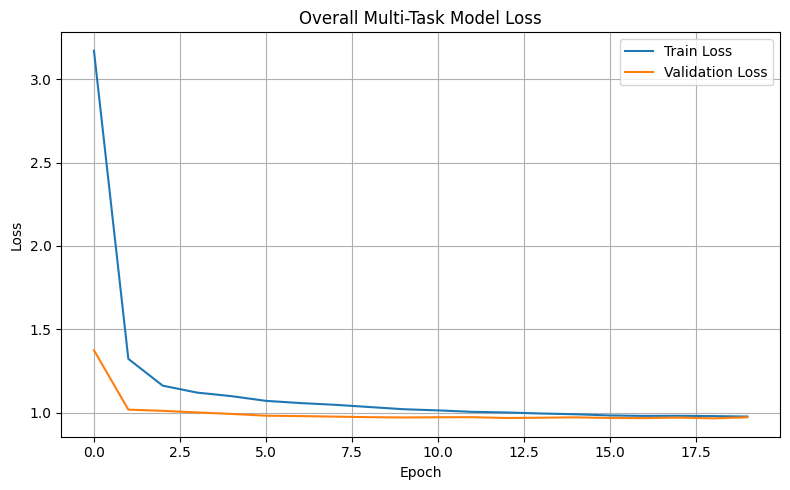

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Overall Multi-Task Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

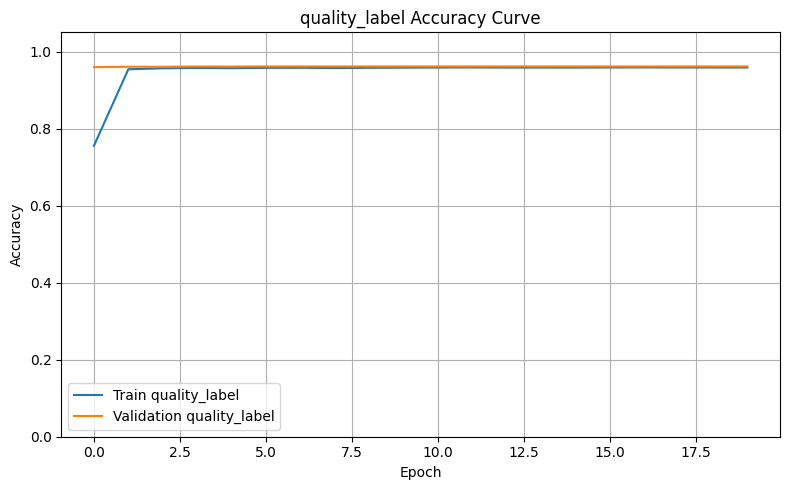

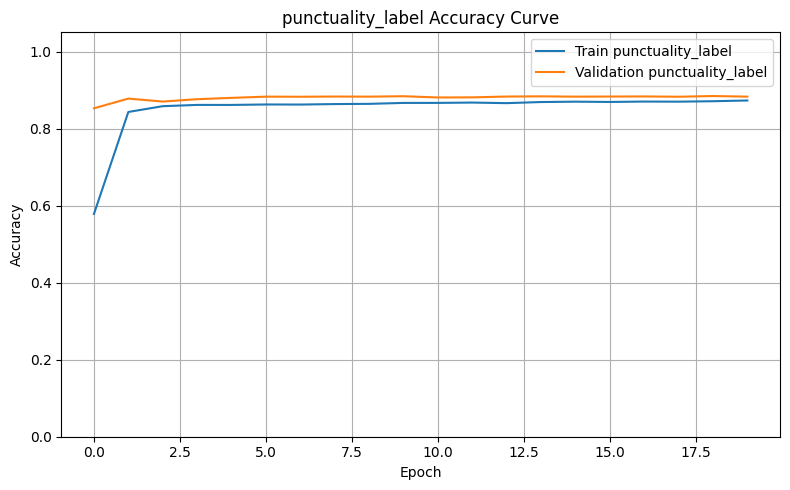

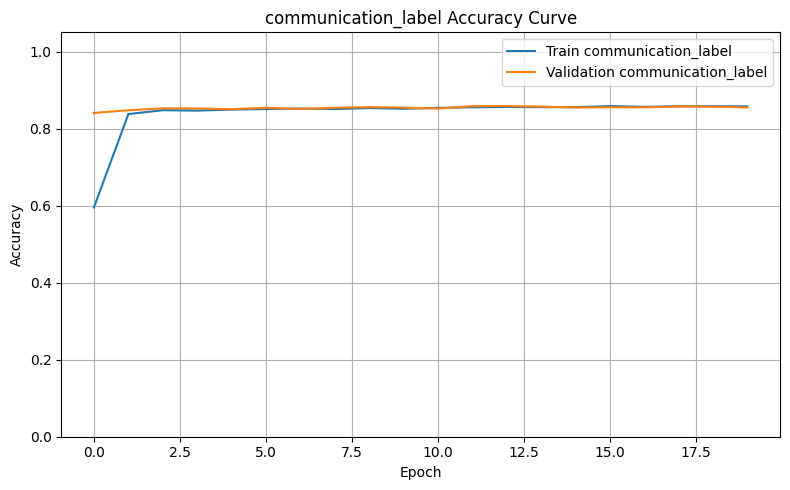

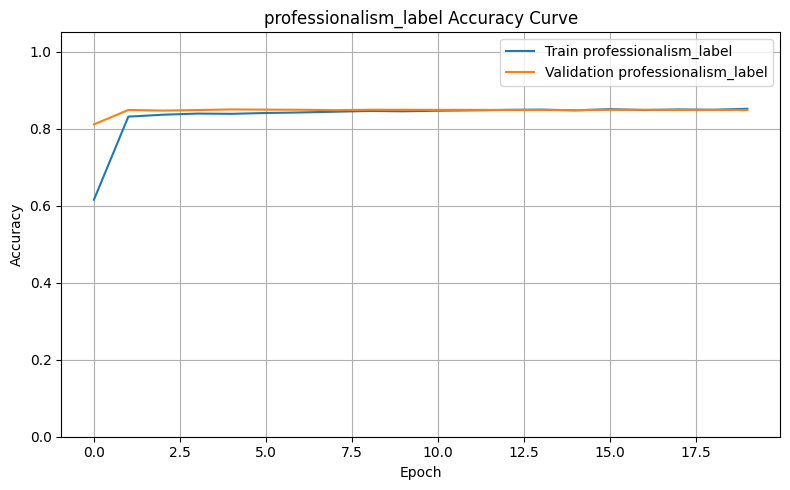

In [ ]:
for aspect in aspect_columns:
    plt.figure(figsize=(8,5))
    plt.plot(history.history[f'{aspect}_accuracy'], label=f'Train {aspect}')
    plt.plot(history.history[f'val_{aspect}_accuracy'], label=f'Validation {aspect}')
    plt.title(f'{aspect} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0,1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
pred_probs = multi_task_model.predict(X_test_text)
aspect_prediction_map = {}
aspect_f1_scores = {}

for idx, aspect in enumerate(aspect_columns):
    y_pred = np.argmax(pred_probs[idx], axis=1)
    aspect_prediction_map[aspect] = y_pred
    print('\n' + '='*70)
    print(f'Classification Report - {aspect}')
    print('='*70)
    print(classification_report(y_test[aspect], y_pred, target_names=label_encoders[aspect].classes_, zero_division=0))
    p, r, f1, s = precision_recall_fscore_support(y_test[aspect], y_pred, average='weighted', zero_division=0)
    aspect_f1_scores[aspect] = f1

118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step

Classification Report - quality_label
              precision    recall  f1-score   support

    Negative       1.00      0.93      0.96       961
     Neutral       1.00      0.93      0.96      1042
    Positive       0.92      1.00      0.96      1770

    accuracy                           0.96      3773
   macro avg       0.97      0.95      0.96      3773
weighted avg       0.96      0.96      0.96      3773


Classification Report - punctuality_label
              precision    recall  f1-score   support

    Negative       0.99      0.77      0.86       929
     Neutral       0.99      0.77      0.87      1031
    Positive       0.80      0.99      0.89      1813

    accuracy                           0.88      3773
   macro avg       0.93      0.84      0.87      3773
weighted avg       0.90      0.88      0.88      3773


Classification Report - communication_label
              precision    recall  f1-score   support

    Negative

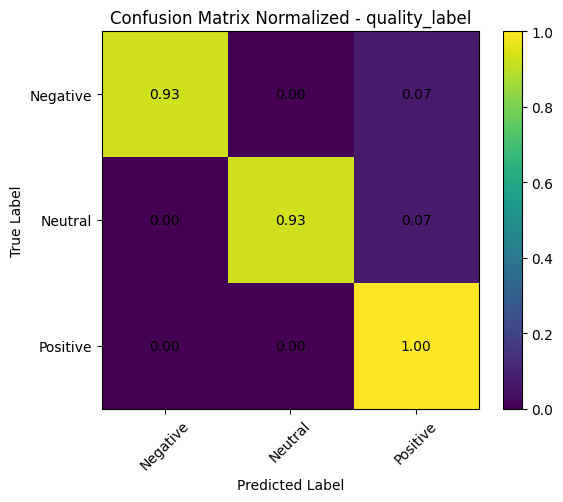

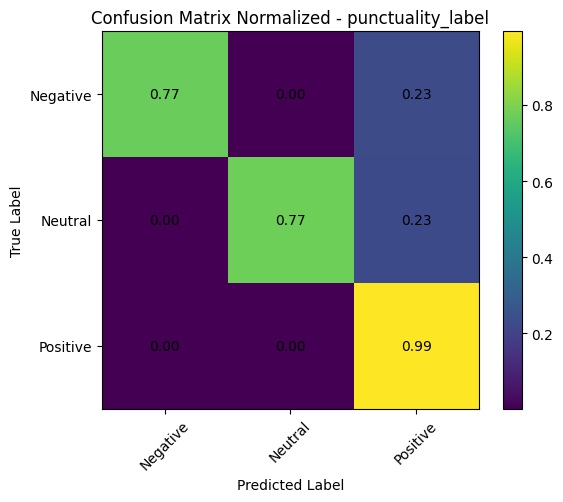

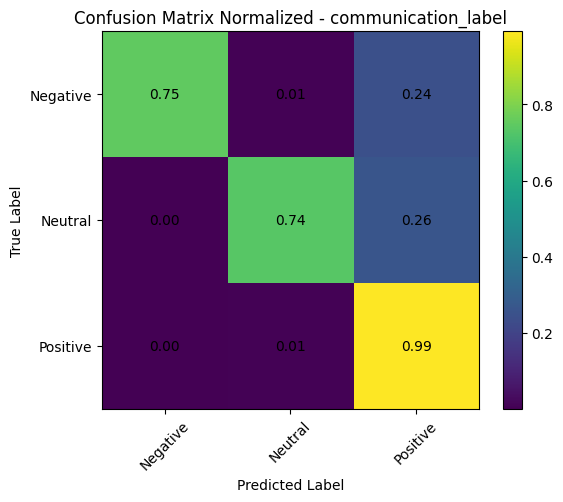

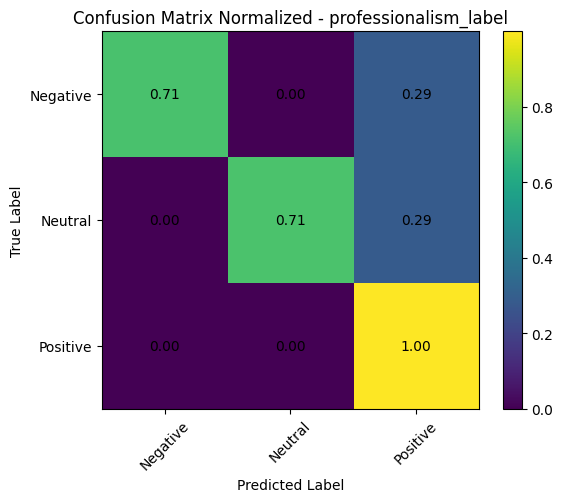

In [ ]:
for aspect in aspect_columns:
    cm = confusion_matrix(y_test[aspect], aspect_prediction_map[aspect], normalize='true')
    plt.figure(figsize=(6,5))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'Confusion Matrix Normalized - {aspect}')
    plt.colorbar()
    classes = label_encoders[aspect].classes_
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center')
    plt.tight_layout()
    plt.show()

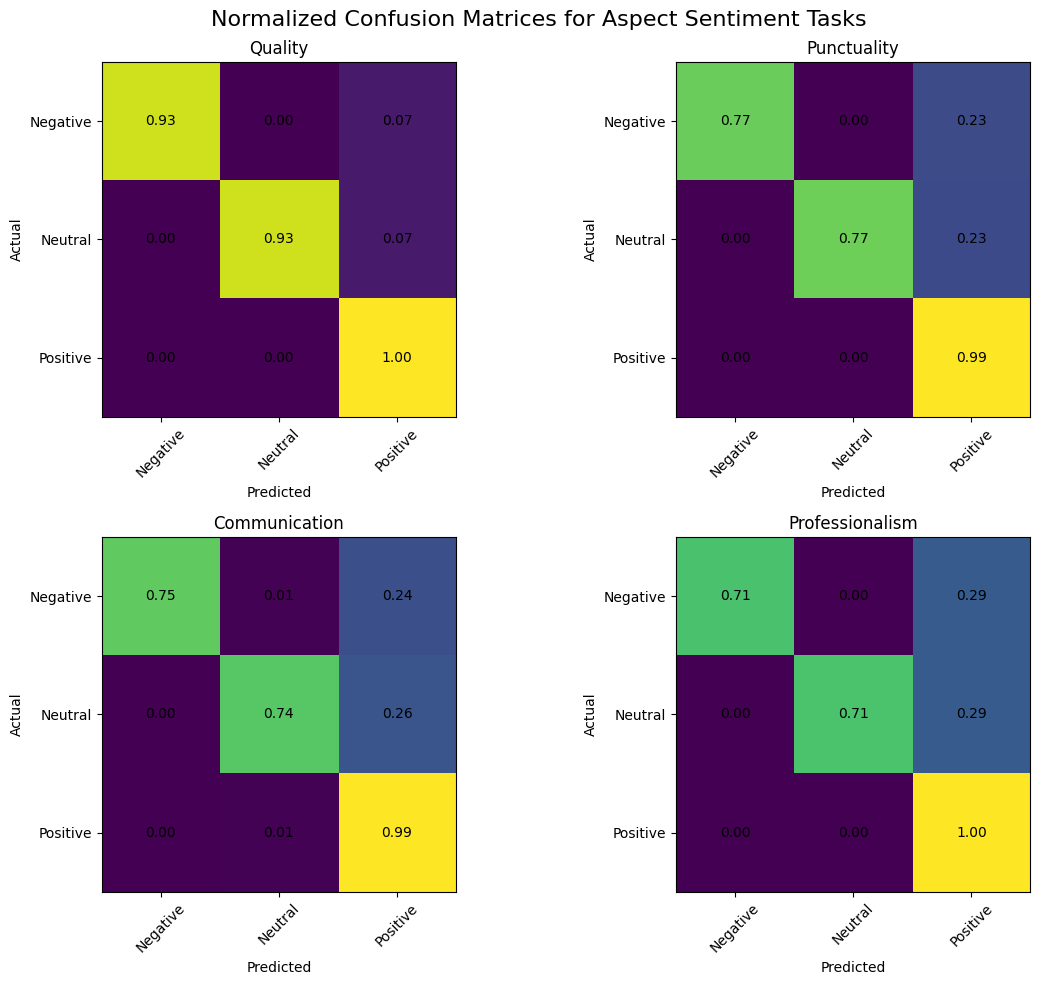

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.ravel()
for idx, aspect in enumerate(aspect_columns):
    cm = confusion_matrix(y_test[aspect], aspect_prediction_map[aspect], normalize='true')
    ax = axes[idx]
    ax.imshow(cm, interpolation='nearest')
    ax.set_title(aspect.replace('_label','').title())
    classes = label_encoders[aspect].classes_
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(classes, rotation=45); ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center')
fig.suptitle('Normalized Confusion Matrices for Aspect Sentiment Tasks', fontsize=16)
plt.tight_layout()
plt.show()

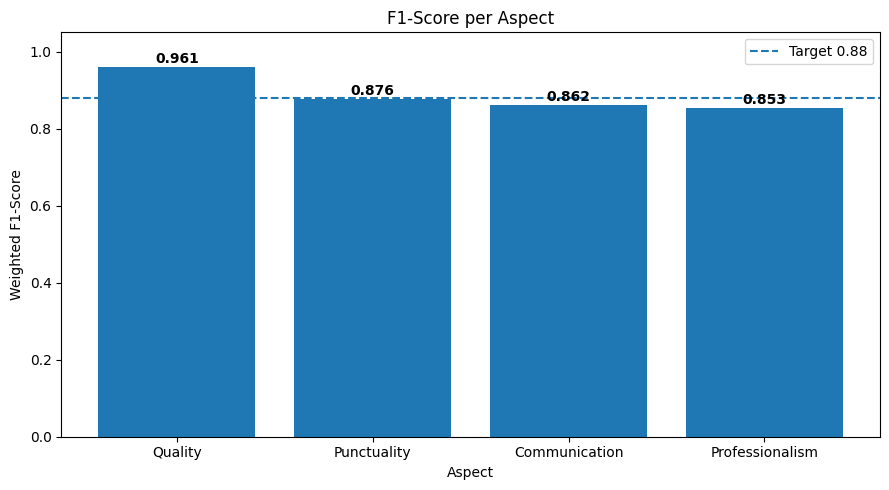

In [ ]:
plt.figure(figsize=(9,5))
aspect_names = [a.replace('_label','').title() for a in aspect_f1_scores.keys()]
f1_values = list(aspect_f1_scores.values())
bars = plt.bar(aspect_names, f1_values)
plt.axhline(0.88, linestyle='--', label='Target 0.88')
for bar, value in zip(bars, f1_values):
    plt.text(bar.get_x()+bar.get_width()/2, value+0.01, f'{value:.3f}', ha='center', fontweight='bold')
plt.title('F1-Score per Aspect')
plt.ylabel('Weighted F1-Score')
plt.xlabel('Aspect')
plt.ylim(0,1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Demo Review Confidence Heatmap

In [ ]:
demo_reviews = [
    'Fixed the AC perfectly but arrived two hours late.',
    'Excellent service, very professional and explained everything clearly.',
    'Not satisfied with the repair quality, the same issue came back again.',
    'Slow response and did not communicate properly about the delay.',
    'Very professional attitude and completed the work neatly.'
]

seq = tokenizer.texts_to_sequences(demo_reviews)
padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
demo_probs = multi_task_model.predict(padded, verbose=0)

confidence_matrix = []
for i in range(len(demo_reviews)):
    row = []
    for aspect_idx, aspect in enumerate(aspect_columns):
        row.append(np.max(demo_probs[aspect_idx][i]))
    confidence_matrix.append(row)
confidence_matrix = np.array(confidence_matrix)

display(pd.DataFrame(confidence_matrix, columns=[a.replace('_label','').title() for a in aspect_columns], index=[f'R{i+1}' for i in range(len(demo_reviews))]))

,Quality,Punctuality,Communication,Professionalism
R1,0.766216,0.978191,0.526634,0.435827
R2,0.933141,0.579258,0.978727,0.528987
R3,0.710677,0.647476,0.470099,0.500233
R4,0.997923,1.000000,0.515926,0.692792
R5,0.751524,0.526501,0.539199,0.576007


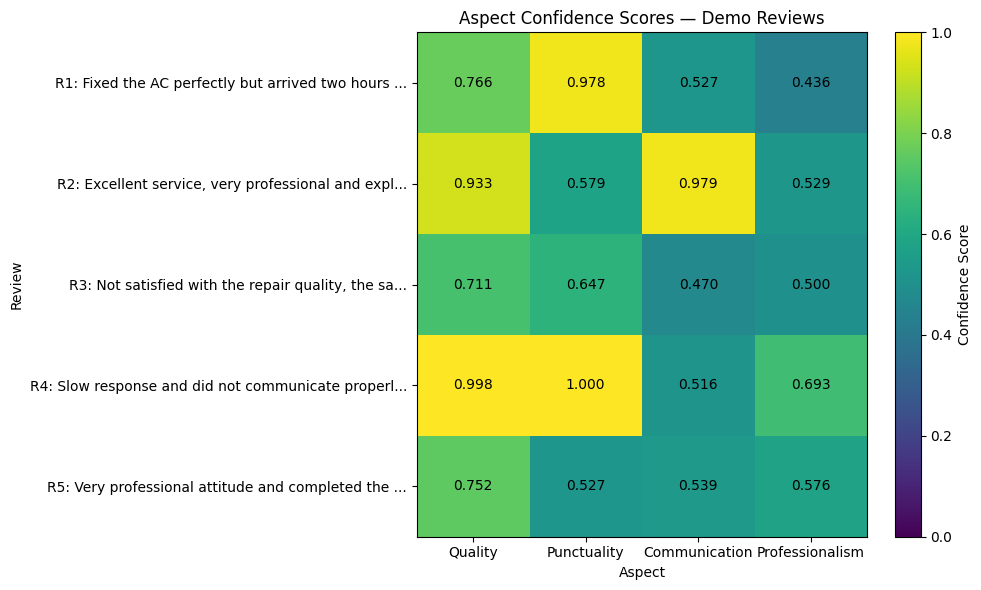

In [ ]:
plt.figure(figsize=(10,6))
plt.imshow(confidence_matrix, aspect='auto', vmin=0, vmax=1)
plt.colorbar(label='Confidence Score')
aspect_names = [a.replace('_label','').title() for a in aspect_columns]
review_names = [f'R{i+1}: {demo_reviews[i][:45]}...' if len(demo_reviews[i]) > 45 else f'R{i+1}: {demo_reviews[i]}' for i in range(len(demo_reviews))]
plt.xticks(np.arange(len(aspect_names)), aspect_names)
plt.yticks(np.arange(len(review_names)), review_names)
plt.title('Aspect Confidence Scores — Demo Reviews')
plt.xlabel('Aspect')
plt.ylabel('Review')
for i in range(confidence_matrix.shape[0]):
    for j in range(confidence_matrix.shape[1]):
        plt.text(j, i, f'{confidence_matrix[i,j]:.3f}', ha='center', va='center')
plt.tight_layout()
plt.show()

In [ ]:
demo_results=[]
for i, review in enumerate(demo_reviews):
    row={'review':review}
    for aspect_idx, aspect in enumerate(aspect_columns):
        pred_id = np.argmax(demo_probs[aspect_idx][i])
        pred_label = label_encoders[aspect].inverse_transform([pred_id])[0]
        confidence = np.max(demo_probs[aspect_idx][i])
        row[aspect.replace('_label','')] = pred_label
        row[aspect.replace('_label','') + '_confidence'] = round(float(confidence), 3)
    demo_results.append(row)
demo_results_df = pd.DataFrame(demo_results)
display(demo_results_df)

,review,quality,quality_confidence,punctuality,punctuality_confidence,communication,communication_confidence,professionalism,professionalism_confidence
0,Fixed the AC perfectly but arrived two hours l...,Positive,0.766,Negative,0.978,Positive,0.527,Positive,0.436
1,"Excellent service, very professional and expla...",Positive,0.933,Positive,0.579,Positive,0.979,Positive,0.529
2,"Not satisfied with the repair quality, the sam...",Neutral,0.711,Positive,0.647,Positive,0.470,Positive,0.500
3,Slow response and did not communicate properly...,Neutral,0.998,Positive,1.000,Positive,0.516,Positive,0.693
4,Very professional attitude and completed the w...,Positive,0.752,Positive,0.527,Positive,0.539,Positive,0.576


# Trust-Aware Fusion and Provider Ranking

In [ ]:
def sentiment_label_to_score(label):
    return 1.0 if label == 'Positive' else 0.5 if label == 'Neutral' else 0.0

test_output = test_df.copy()
for idx, aspect in enumerate(aspect_columns):
    pred_ids = aspect_prediction_map[aspect]
    pred_labels = label_encoders[aspect].inverse_transform(pred_ids)
    test_output[f'pred_{aspect}'] = pred_labels
    test_output[f'pred_{aspect}_score'] = [sentiment_label_to_score(x) for x in pred_labels]

aspect_weights = {'quality_label':0.35,'punctuality_label':0.25,'communication_label':0.20,'professionalism_label':0.20}
test_output['aspect_weighted_score'] = 0
for aspect, weight in aspect_weights.items():
    test_output['aspect_weighted_score'] += test_output[f'pred_{aspect}_score'] * weight

test_output['trust_sentiment_score'] = test_output['aspect_weighted_score'] * test_output['predicted_credibility_score']
display(test_output.head())

,review_id,booking_id,provider_id,user_id,service_type,district,rating,review_text,review_date,verified_booking_x,...,pred_quality_label,pred_quality_label_score,pred_punctuality_label,pred_punctuality_label_score,pred_communication_label,pred_communication_label_score,pred_professionalism_label,pred_professionalism_label_score,aspect_weighted_score,trust_sentiment_score
1,R00002,B380896,P020134,U71066,Carpenters,Nuwara Eliya,5,Perfect work 100% recommended visit http://ser...,2025-11-27,0,...,Positive,1.0,Positive,1.0,Positive,1.0,Positive,1.0,1.000,0.098974
47,R00048,B836357,P060234,U60004,Technicians,Jaffna,2,"For the motor service, finish eka okay but not...",2025-02-21,1,...,Neutral,0.5,Negative,0.0,Neutral,0.5,Negative,0.0,0.275,0.238371
53,R00054,B876798,P120274,U26375,Well Services,Ratnapura,3,"For the water level issue, water level water l...",2026-02-08,1,...,Negative,0.0,Positive,1.0,Positive,1.0,Neutral,0.5,0.550,0.468543
68,R00069,B988266,P130138,U10862,Cushion Works,Nuwara Eliya,3,"For the seat repair, quality eka average, came...",2026-01-12,0,...,Neutral,0.5,Neutral,0.5,Negative,0.0,Neutral,0.5,0.400,0.396294
70,R00071,B428949,P010249,U73126,Masons,Kalutara,4,"Overall, work quality was very good, small del...",2025-09-23,1,...,Positive,1.0,Neutral,0.5,Positive,1.0,Positive,1.0,0.875,0.684583


In [ ]:
rating_col = 'rating_x' if 'rating_x' in test_output.columns else 'rating'
provider_rankings = test_output.groupby(['provider_id','service_type']).agg(
    total_reviews=('review_id','count'),
    avg_rating=(rating_col,'mean'),
    avg_credibility=('predicted_credibility_score','mean'),
    avg_trust_sentiment=('trust_sentiment_score','mean'),
    fake_review_count=('predicted_fake_review','sum')
).reset_index()

provider_rankings['final_provider_score'] = (0.60*provider_rankings['avg_trust_sentiment'] + 0.25*provider_rankings['avg_credibility'] + 0.15*(provider_rankings['avg_rating']/5.0))
provider_rankings = provider_rankings.sort_values('final_provider_score', ascending=False)
display(provider_rankings.head(10))

,provider_id,service_type,total_reviews,avg_rating,avg_credibility,avg_trust_sentiment,fake_review_count,final_provider_score
633,P040089,Plumbers,1,4.0,0.995494,0.995494,0,0.966170
1611,P090153,Cleaners,1,4.0,0.995494,0.995494,0,0.966170
541,P030267,Tile Workers,1,4.0,0.995494,0.995494,0,0.966170
886,P050245,Electricians,1,4.0,0.995494,0.995494,0,0.966170
164,P010285,Masons,1,4.0,0.990511,0.990511,0,0.961934
1213,P070120,Painters,1,4.0,0.990511,0.990511,0,0.961934
487,P030157,Tile Workers,1,4.0,0.990511,0.990511,0,0.961934
1651,P090222,Cleaners,1,4.0,0.990511,0.990511,0,0.961934
2203,P120290,Well Services,1,4.0,0.990333,0.990333,0,0.961783
2169,P120225,Well Services,1,4.0,0.990333,0.990333,0,0.961783


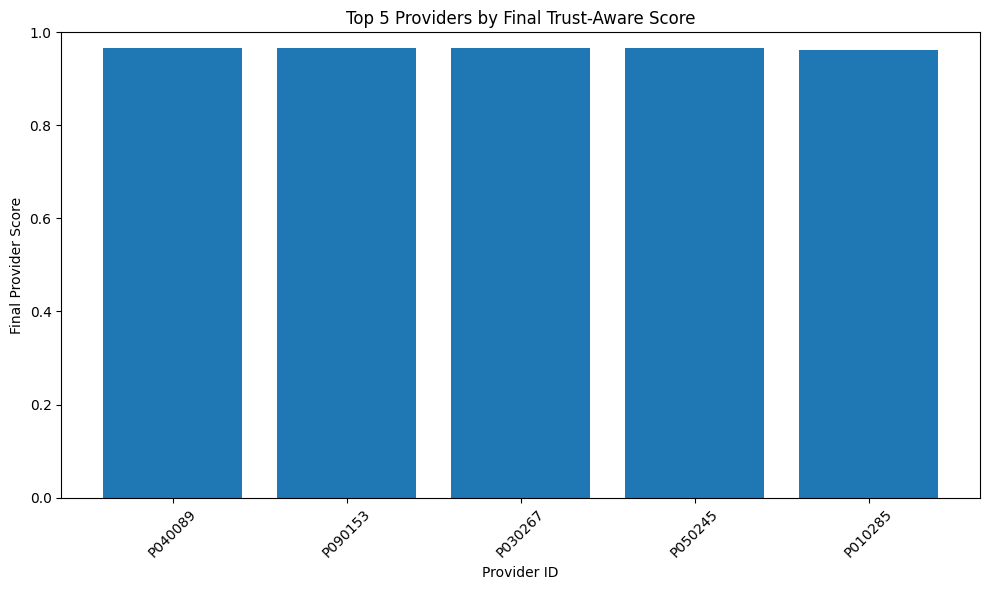

In [ ]:
top5 = provider_rankings.head(5)
plt.figure(figsize=(10,6))
plt.bar(top5['provider_id'], top5['final_provider_score'])
plt.title('Top 5 Providers by Final Trust-Aware Score')
plt.xlabel('Provider ID')
plt.ylabel('Final Provider Score')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.tight_layout()
plt.show()

In [ ]:
def explain_score(row):
    if row['final_provider_score'] >= 0.80:
        tier = 'Elite'
    elif row['final_provider_score'] >= 0.65:
        tier = 'Trusted'
    else:
        tier = 'Verified'
    return f"{tier} provider with trust sentiment {row['avg_trust_sentiment']:.2f}, credibility {row['avg_credibility']:.2f}, and {int(row['total_reviews'])} analysed reviews."

provider_rankings['explanation'] = provider_rankings.apply(explain_score, axis=1)
display(provider_rankings[['provider_id','service_type','total_reviews','avg_rating','avg_credibility','avg_trust_sentiment','final_provider_score','explanation']].head(10))

,provider_id,service_type,total_reviews,avg_rating,avg_credibility,avg_trust_sentiment,final_provider_score,explanation
633,P040089,Plumbers,1,4.0,0.995494,0.995494,0.966170,"Elite provider with trust sentiment 1.00, cred..."
1611,P090153,Cleaners,1,4.0,0.995494,0.995494,0.966170,"Elite provider with trust sentiment 1.00, cred..."
541,P030267,Tile Workers,1,4.0,0.995494,0.995494,0.966170,"Elite provider with trust sentiment 1.00, cred..."
886,P050245,Electricians,1,4.0,0.995494,0.995494,0.966170,"Elite provider with trust sentiment 1.00, cred..."
164,P010285,Masons,1,4.0,0.990511,0.990511,0.961934,"Elite provider with trust sentiment 0.99, cred..."
1213,P070120,Painters,1,4.0,0.990511,0.990511,0.961934,"Elite provider with trust sentiment 0.99, cred..."
487,P030157,Tile Workers,1,4.0,0.990511,0.990511,0.961934,"Elite provider with trust sentiment 0.99, cred..."
1651,P090222,Cleaners,1,4.0,0.990511,0.990511,0.961934,"Elite provider with trust sentiment 0.99, cred..."
2203,P120290,Well Services,1,4.0,0.990333,0.990333,0.961783,"Elite provider with trust sentiment 0.99, cred..."
2169,P120225,Well Services,1,4.0,0.990333,0.990333,0.961783,"Elite provider with trust sentiment 0.99, cred..."


# Save Models and Outputs

In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/Research_Datasets/Component4_Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

multi_task_model.save(f'{OUTPUT_DIR}/component4_multitask_bilstm_attention.keras')
joblib.dump(tokenizer, f'{OUTPUT_DIR}/component4_tokenizer.pkl')
joblib.dump(label_encoders, f'{OUTPUT_DIR}/component4_label_encoders.pkl')
joblib.dump(iso_forest, f'{OUTPUT_DIR}/component4_isolation_forest.pkl')
joblib.dump(scaler, f'{OUTPUT_DIR}/component4_fake_feature_scaler.pkl')
provider_rankings.to_csv(f'{OUTPUT_DIR}/component4_provider_rankings.csv', index=False)
test_output.to_csv(f'{OUTPUT_DIR}/component4_test_predictions.csv', index=False)
print('Saved outputs to:', OUTPUT_DIR)

Saved outputs to: /content/drive/MyDrive/Research_Datasets/Component4_Outputs


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Detect trained model
if "multi_task_model" in globals():
    trained_model = multi_task_model
    print("Using model: multi_task_model")
elif "model" in globals():
    trained_model = model
    print("Using model: model")
else:
    raise NameError("No trained model found. Run the model training cell first.")

print("="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

# Predict
pred_probs = trained_model.predict(X_test_text)

if not isinstance(pred_probs, list):
    pred_probs = [pred_probs]

aspect_columns = [
    "quality_label",
    "punctuality_label",
    "communication_label",
    "professionalism_label"
]

accuracies = []

for i, aspect in enumerate(aspect_columns[:len(pred_probs)]):

    y_pred = np.argmax(pred_probs[i], axis=1)

    if isinstance(y_test, dict):
        y_true = y_test[aspect]
    else:
        y_true = y_test

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    accuracies.append(acc)

    print("\n" + "="*50)
    print(aspect.upper())
    print("="*50)
    print("Accuracy  :", round(acc * 100, 2), "%")
    print("Precision :", round(pre * 100, 2), "%")
    print("Recall    :", round(rec * 100, 2), "%")
    print("F1 Score  :", round(f1 * 100, 2), "%")

print("\nAverage Test Accuracy:", round(np.mean(accuracies) * 100, 2), "%")

print("\nTraining / Validation Accuracy")
print("="*70)

for key, value in history.history.items():
    if "acc" in key.lower() or "accuracy" in key.lower():
        print(key, ":", round(value[-1] * 100, 2), "%")

Using model: multi_task_model
FINAL MODEL EVALUATION
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step

QUALITY_LABEL
Accuracy  : 96.1 %
Precision : 96.4 %
Recall    : 96.1 %
F1 Score  : 96.11 %

PUNCTUALITY_LABEL
Accuracy  : 87.73 %
Precision : 89.88 %
Recall    : 87.73 %
F1 Score  : 87.61 %

COMMUNICATION_LABEL
Accuracy  : 86.35 %
Precision : 88.86 %
Recall    : 86.35 %
F1 Score  : 86.16 %

PROFESSIONALISM_LABEL
Accuracy  : 85.58 %
Precision : 88.76 %
Recall    : 85.58 %
F1 Score  : 85.28 %

Average Test Accuracy: 88.94 %

Training / Validation Accuracy
communication_label_accuracy : 85.78 %
professionalism_label_accuracy : 85.15 %
punctuality_label_accuracy : 87.3 %
quality_label_accuracy : 95.86 %
val_communication_label_accuracy : 85.51 %
val_professionalism_label_accuracy : 84.84 %
val_punctuality_label_accuracy : 88.3 %
val_quality_label_accuracy : 96.14 %


In [ ]:
summary_data = []

# Extract Test Metrics
for i, aspect in enumerate(aspect_columns):
    y_pred = np.argmax(pred_probs[i], axis=1)
    y_true = y_test[aspect]

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    summary_data.append({
        'Aspect': aspect.replace('_label', '').title(),
        'Test Accuracy': round(acc * 100, 2),
        'Test Precision': round(pre * 100, 2),
        'Test Recall': round(rec * 100, 2),
        'Test F1 Score': round(f1 * 100, 2),
        'Train Accuracy': round(history.history[f'{aspect}_accuracy'][-1] * 100, 2),
        'Validation Accuracy': round(history.history[f'val_{aspect}_accuracy'][-1] * 100, 2)
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Aspect,Test Accuracy,Test Precision,Test Recall,Test F1 Score,Train Accuracy,Validation Accuracy
0,Quality,96.10,96.40,96.10,96.11,95.86,96.14
1,Punctuality,87.73,89.88,87.73,87.61,87.30,88.30
2,Communication,86.35,88.86,86.35,86.16,85.78,85.51
3,Professionalism,85.58,88.76,85.58,85.28,85.15,84.84
